In [1]:
from pathlib import Path

DATASET_PATH = "./Sign Language Detection/babeczka"
root = Path(DATASET_PATH)
assert root.exists(), f"Dataset path not found: {DATASET_PATH}. Change DATASET_PATH to correct folder."
print(root)

Sign Language Detection/babeczka


In [2]:
train_images = root / "train" / "images"
train_labels = root / "train" / "labels"

test_images = root / "test" / "images"
test_labels = root / "test" / "labels"
print("Train images path:", train_images)
print("Train labels path:", train_labels)

Train images path: Sign Language Detection/babeczka/train/images
Train labels path: Sign Language Detection/babeczka/train/labels


Wytrenowany model do detekcji współrzędnych dłoni

In [3]:
import tensorflow as tf

# Wczytanie modelu
hand_detector = tf.keras.models.load_model('hand_detector_best.keras')
hand_detector

2026-01-30 16:16:52.019655: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 16:16:53.061549: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-30 16:17:08.181998: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1769786240.641969   26920 gpu_device.cc:2020] Created de

<Functional name=functional, built=True>

In [4]:
for p in [train_images, train_labels]:
    if not p.exists():
        print("Warning: path not found ->", p)

print("Train images:", len(list(train_images.glob("*.*"))))

Train images: 298


Showing sample: hello_2cdf95c0-7a66-11ed-a1fd-1e08bc6ed8a6_jpg.rf.922a56f4e49598a43d24e38ba503740f.jpg


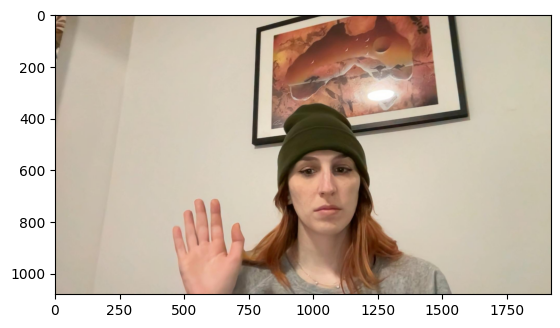

In [5]:
import matplotlib.pyplot as plt

# show one sample (if exists)
sample_imgs = list(train_images.glob("*.*"))
if sample_imgs:
    sample_img = sample_imgs[0]
    sample_label = train_labels / (sample_img.stem + ".txt")
    print("Showing sample:", sample_img.name)
    plt.imshow(plt.imread(sample_img))
else:
    print("No images found in train/images.")

In [6]:
IMG_SIZE = 400

In [7]:
NUMBER_OF_CLASSES = 5

In [8]:
import cv2
import numpy as np

def crop_hand(image_path, model):
    # 1. Przygotuj obraz
    original_img = cv2.imread(image_path)
    img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    input_tensor = np.expand_dims(img_resized, axis=0)

    # 2. Predykcja ramki
    box = model.predict(input_tensor)[0] # [x, y, w, h] (znormalizowane)
    
    # 3. Przelicz na piksele
    h_orig, w_orig, _ = original_img.shape
    x = int(box[0] * w_orig)
    y = int(box[1] * h_orig)
    w = int(box[2] * w_orig)
    h = int(box[3] * h_orig)

    # Zabezpieczenia (żeby nie wyjść poza obraz przy błędzie modelu)
    x = max(0, x)
    y = max(0, y)
    
    # 4. Wycięcie (Crop)
    # Dodajemy mały margines (padding), żeby nie uciąć palców
    padding = 20
    crop = original_img[y-padding : y+h+padding, x-padding : x+w+padding]
    
    return crop, (x, y, w, h)

In [9]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Zakładamy, że detektor był trenowany na 224x224 (zgodnie z naszą poprzednią rozmową)
DETECTOR_SIZE = (IMG_SIZE, IMG_SIZE) 

def load_data_with_detection(img_dir, label_dir, detector_model):
    images = []
    labels = []
    
    img_files = sorted(list(img_dir.glob("*.*")))
    
    print(f"Przetwarzanie {len(img_files)} obrazów z detekcją dłoni...")

    for i, img_path in enumerate(img_files):
        cropped_img, coords = crop_hand(img_path, detector_model)

        # ---------------------------------------------------------
        # ETAP 2: PRZYGOTOWANIE POD KLASYFIKATOR
        # ---------------------------------------------------------
        
        # Resize wycinka do rozmiaru docelowego klasyfikatora (IMG_SIZE)
        hand_crop_resized = cv2.resize(cropped_img, (IMG_SIZE, IMG_SIZE))
        images.append(hand_crop_resized)
        
        # Wczytanie etykiety (bez zmian)
        label_path = label_dir / (img_path.stem + ".txt")
        if label_path.exists():
            with open(label_path, 'r') as f:
                first_line = f.readline().split()
                if first_line:
                    labels.append(int(first_line[0]))
        else:
            labels.append(0)
            
        # Opcjonalnie: Pokaż postęp co 100 zdjęć
        if i % 100 == 0:
            print(f"Przetworzono {i}/{len(img_files)}")

    print("Zakończono wczytywanie.")
    return np.array(images) / 255.0, to_categorical(np.array(labels), num_classes=NUMBER_OF_CLASSES)

In [10]:
X_train, y_train = load_data_with_detection(train_images, train_labels, hand_detector)

Przetwarzanie 298 obrazów z detekcją dłoni...


2026-01-30 16:17:23.645403: I external/local_xla/xla/service/service.cc:163] XLA service 0x714fe0002dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-30 16:17:23.645434: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 SUPER, Compute Capability 8.9
2026-01-30 16:17:23.712176: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-30 16:17:24.077088: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-01-30 16:17:29.727475: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-30 16:17:29.859050: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Przetworzono 0/298
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/

In [11]:
X_train.shape

(298, 400, 400, 3)

In [12]:
X_test, y_test = load_data_with_detection(test_images, test_labels, hand_detector)

Przetwarzanie 42 obrazów z detekcją dłoni...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Przetworzono 0/42
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [13]:
from keras import backend as K

print(K.image_data_format())

channels_last


In [14]:
# from keras import layers, models, regularizers

# def residual_block(x, filters, kernel_size=3, stride=1):
#     shortcut = x
    
#     # --- Główna ścieżka ---
#     # 1. Konwolucja
#     x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=False)(x)
#     # 2. Batch Norm (KLUCZ DO SUKCESU)
#     x = layers.BatchNormalization()(x)
#     # 3. Aktywacja
#     x = layers.Activation('relu')(x)
    
#     # 4. Druga konwolucja
#     x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
#     x = layers.BatchNormalization()(x)
    
#     # --- Obsługa skrótu (Shortcut) ---
#     # Jeśli zmieniamy wymiary (stride > 1) lub liczbę filtrów, musimy dopasować skrót
#     if x.shape[-1] != shortcut.shape[-1] or stride > 1:
#         shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same', use_bias=False)(shortcut)
#         shortcut = layers.BatchNormalization()(shortcut)
        
#     # --- Połączenie ---
#     x = layers.Add()([x, shortcut])
#     x = layers.Activation('relu')(x)
#     return x

# def build_improved_resnet(img_size, num_classes):
#     inputs = layers.Input(shape=(img_size, img_size, 3))
    
#     # Wejściowa warstwa - agresywniejsza (stride=2) by zmniejszyć obraz na start
#     x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False)(inputs)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation('relu')(x)
#     x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
    
#     # Bloki rezydualne (Coraz więcej filtrów)
#     x = residual_block(x, 64)
#     x = residual_block(x, 64)
    
#     x = residual_block(x, 128, stride=2) # stride=2 zmniejsza obraz o połowę
#     x = residual_block(x, 128)
    
#     x = residual_block(x, 256, stride=2)
#     x = residual_block(x, 256)
    
#     # Zakończenie
#     x = layers.GlobalAveragePooling2D()(x)
    
#     x = layers.Dense(256, activation='relu')(x)
#     x = layers.Dropout(0.5)(x) # Ważne przy małym datasecie!
    
#     outputs = layers.Dense(num_classes, activation='softmax')(x)
    
#     model = models.Model(inputs, outputs)
#     return model

# # Budowa modelu
# model = build_improved_resnet(IMG_SIZE, NUMBER_OF_CLASSES)
# model.summary()

from tensorflow.keras import layers, models

model = models.Sequential([
    # Pierwsza warstwa splotowa - wyciąga krawędzie i proste wzory
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Druga warstwa - bardziej złożone kształty dłoni
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Trzecia warstwa
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Spłaszczenie danych do warstw gęstych (klasyfikatora)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Zapobiega przeuczeniu
    layers.Dense(NUMBER_OF_CLASSES, activation='softmax') # 5 wyjść (dla każdej klasy znaku)
])

model.summary()

/mnt/d/Magisterka/Semestr 3/Uczenie Glebokie L/hand-sign-recognition/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 398, 398, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 199, 199, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 197, 197, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 294912)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    37,748,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,842,757 (144.36 MB)

 Trainable params: 37,842,757 (144.36 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [16]:
# Callbacks - Zatrzymanie treningu, gdy model przestanie się uczyć
callbacks = [
    # tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001),
     # Zapisz model tylko, gdy wynik na walidacji się poprawi
    tf.keras.callbacks.ModelCheckpoint(
        'gesture_classifier.keras', 
        save_best_only=True, 
        monitor='val_loss'
    ),
]

In [17]:
# Start treningu
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.2248 - loss: 3.2768 - val_accuracy: 0.2619 - val_loss: 1.5714 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 358ms/step - accuracy: 0.4027 - loss: 1.3619 - val_accuracy: 0.5238 - val_loss: 1.1862 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 362ms/step - accuracy: 0.5403 - loss: 1.0499 - val_accuracy: 0.6429 - val_loss: 1.0434 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 353ms/step - accuracy: 0.6678 - loss: 0.9425 - val_accuracy: 0.7143 - val_loss: 1.0064 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 351ms/step - accuracy: 0.7483 - loss: 0.6763 - val_accuracy: 0.8333 - val_loss: 0.5686 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8523 - loss: 0.3619 - val_accuracy: 0.8333 - val_loss: 0.6319 - learning_rate: 0.0010
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 363ms/step - accuracy: 0.8792 - loss: 0.3586 - val

In [18]:
score = model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9762 - loss: 0.0773


In [19]:
from pathlib import Path
import yaml

data_path = root / "data.yaml"

with data_path.open("r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

CLASSES = data["names"]          # list of class names
amount = data.get("nc", len(CLASSES))
print("names:", CLASSES)

names: ['hello', 'iloveyou', 'no', 'thanks', 'yes']


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step


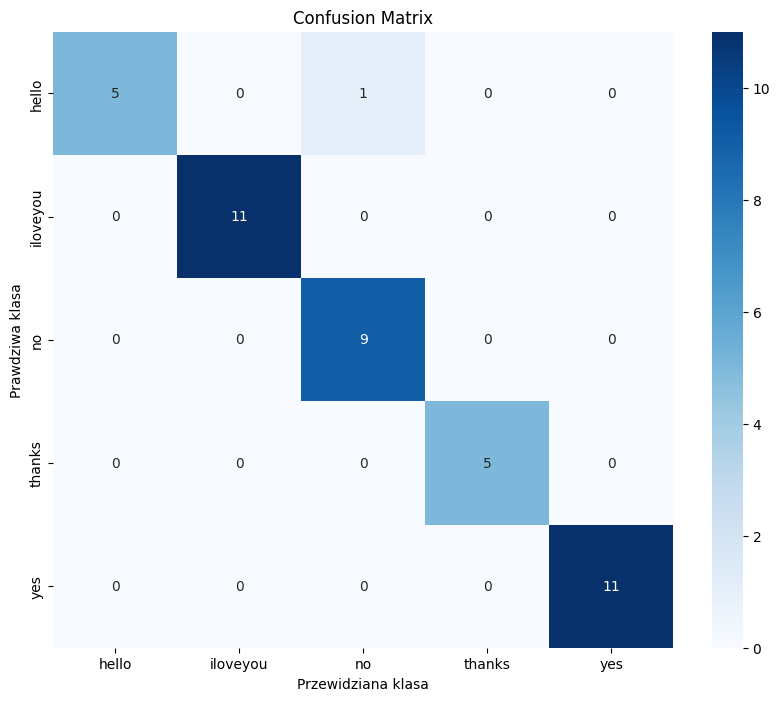

              precision    recall  f1-score   support

       hello       1.00      0.83      0.91         6
    iloveyou       1.00      1.00      1.00        11
          no       0.90      1.00      0.95         9
      thanks       1.00      1.00      1.00         5
         yes       1.00      1.00      1.00        11

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.97        42
weighted avg       0.98      0.98      0.98        42



In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Predykcja na zbiorze testowym
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Macierz pomyłek
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Wykres
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.title('Confusion Matrix')
plt.show()

# 4. Raport tekstowy
print(classification_report(y_true, y_pred_classes, target_names=CLASSES))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predykcja: iloveyou z pewnością 99.60%


QFontDatabase: Cannot find font directory /mnt/d/Magisterka/Semestr 3/Uczenie Glebokie L/hand-sign-recognition/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /mnt/d/Magisterka/Semestr 3/Uczenie Glebokie L/hand-sign-recognition/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /mnt/d/Magisterka/Semestr 3/Uczenie Glebokie L/hand-sign-recognition/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /mnt/d/Magisterka/Semestr 3/Uczenie Glebokie L/hand-sign-recognition/.venv/lib/python3.12/site-packages/cv

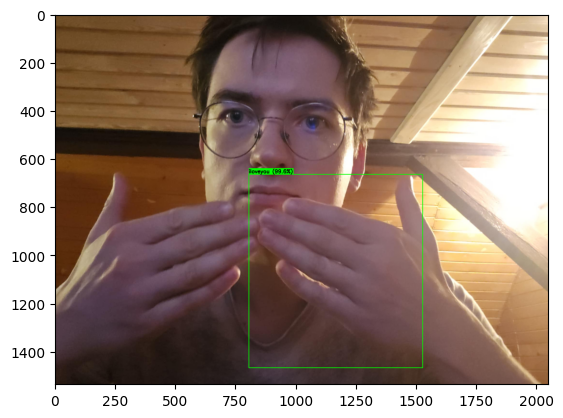

In [21]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def predict_full_pipeline(image_path, detector_model, classifier_model, classes_list):
    img_bgr = cv2.imread(image_path)
    hand_crop, coords = crop_hand(image_path, detector_model)
    x_pad = coords[0]
    y_pad = coords[1]
    w_pad = coords[2]
    h_pad = coords[3]

    # Zabezpieczenie przed pustym wycinkiem (gdyby detektor zawiódł)
    if hand_crop.size == 0:
        print("Nie udało się wyciąć dłoni (błąd detektora).")
        return

    # =========================================================
    # KROK 2: KLASYFIKACJA (Jaki to gest?)
    # =========================================================

    # Preprocessing dla klasyfikatora
    img_cls = cv2.resize(hand_crop, (IMG_SIZE, IMG_SIZE)) / 255.0
    img_cls_batch = np.expand_dims(img_cls, axis=0)

    # Predykcja gestu
    predictions = classifier_model.predict(img_cls_batch, verbose=0)[0]
    class_idx = np.argmax(predictions)       # Indeks najwyższego wyniku
    confidence = predictions[class_idx]      # Pewność (0.0 - 1.0)
    
    predicted_label = classes_list[class_idx]
    
    print(f"Predykcja: {predicted_label} z pewnością {confidence*100:.2f}%")

    # =========================================================
    # KROK 3: WIZUALIZACJA
    # =========================================================
    
    # Kolor ramki zależny od pewności (Zielony = pewny, Żółty = niepewny)
    color = (0, 255, 0) if confidence > 0.7 else (0, 255, 255)

    # Rysujemy ramkę na ORYGINALNYM obrazie BGR
    cv2.rectangle(img_bgr, (x_pad, y_pad), (x_pad + w_pad, y_pad + h_pad), color, 2)

    # Przygotowanie tekstu: "I love You (98%)"
    text = f"{predicted_label} ({confidence*100:.1f}%)"
    
    # Tło pod napisem (dla czytelności)
    (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    cv2.rectangle(img_bgr, (x_pad, y_pad - 25), (x_pad + text_w, y_pad), color, -1)
    
    # Napis
    cv2.putText(img_bgr, text, (x_pad, y_pad - 5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

    # Pokazanie wyniku
    cropped_img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.imshow(cropped_img_rgb)
    # cv2.imshow("Wynik Pipeline", img_bgr)
    
    # Opcjonalnie: Pokaż też, co "widział" klasyfikator (wycinek)
    cv2.imshow("Co widzi klasyfikator", cv2.cvtColor(hand_crop, cv2.COLOR_RGB2BGR))
    
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# -----------------------------------------------------------
# PRZYKŁAD UŻYCIA
# -----------------------------------------------------------

detector = tf.keras.models.load_model('hand_detector_best.keras')
classifier = tf.keras.models.load_model('gesture_classifier.keras')

# Uruchomienie funkcji
# predict_full_pipeline("Sign Language Detection/babeczka/test/images/thanks_6c96cd1e-7a66-11ed-a1fd-1e08bc6ed8a6_jpg.rf.e5bacbdc5b8d8be361acd4b88a2ecfb9.jpg", detector, classifier, CLASSES)
predict_full_pipeline("./test.jpg", detector, classifier, CLASSES)